# Thực hành Buổi 12: Supervised Machine Learning Pipeline — Churn Prediction

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Scikit-Learn Pipeline, Confusion Matrix, ROC-AUC

**Đầu vào ➔ Đầu ra:** `customer_churn.csv` ➔ **mô hình phân loại + bảng đo metric** (`data/processed/lab12_metrics.csv`, `data/processed/churn_model.joblib`)

> **Vị trí trong chuỗi bài:** Bài 7 đã "chế biến" đặc trưng thủ công; buổi này đóng gói toàn bộ tiền xử lý + mô hình vào **một `Pipeline` duy nhất** — chuẩn công nghiệp để tránh rò rỉ dữ liệu (data leakage) và để mô hình triển khai được. Bài toán: dự đoán khách hàng **rời bỏ (churn)** bằng Logistic Regression và Decision Tree.

> ⚠️ **Điều kiện tiên quyết:** chạy xong `lab6/Lab6.ipynb`.

**Ba nguyên tắc xuyên suốt buổi học:**
1. **Chia train/test TRƯỚC, mọi thứ fit SAU** — scaler/encoder chỉ được học trên train;
2. **Mọi tiền xử lý nằm TRONG Pipeline** — một đối tượng duy nhất từ dữ liệu thô đến dự đoán;
3. **Accuracy không đủ** — với bài toán lệch lớp phải nhìn Confusion Matrix, Precision/Recall và ROC-AUC.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RAW = Path("../data/raw"); PROCESSED = Path("../data/processed")
kh = pd.read_csv(RAW / "customer_churn.csv")
print(f"{len(kh):,} khách hàng | tỷ lệ churn = {kh['churn'].mean():.1%}")
kh.head()

8,000 khách hàng | tỷ lệ churn = 35.1%


,customer_id,age,gender,city,tenure_months,support_tickets,churn
0,C00001,47,Nữ,Hà Nội,15,1,0
1,C00002,32,Nam,Đà Nẵng,20,2,0
2,C00003,38,Nam,Cần Thơ,54,1,0
3,C00004,60,Nam,TP HCM,37,2,0
4,C00005,23,Nữ,TP HCM,39,0,0


## 12.1. Ghép đặc trưng hành vi và khám phá nhanh

Hồ sơ (`age`, `gender`, `city`, `tenure_months`, `support_tickets`) chưa đủ — hành vi mua sắm mới là tín hiệu mạnh. Ghép gọn 3 chỉ số RFM từ dataset giao dịch sạch (phiên bản rút gọn của Bài 7):

In [2]:
tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
tx_ht = tx[tx["status"] == "HOAN_TAT"]
moc = tx_ht["ts"].max() + pd.Timedelta(days=1)
rfm = (tx_ht.groupby("customer_id")
       .agg(recency=("ts", lambda s: (moc - s.max()).days),
            frequency=("transaction_id", "size"),
            monetary=("amount", "sum")))

du_lieu = kh.merge(rfm, left_on="customer_id", right_index=True, how="left")
du_lieu[["recency", "frequency", "monetary"]] = \
    du_lieu[["recency", "frequency", "monetary"]].fillna({"recency": 999,
                                                          "frequency": 0, "monetary": 0})
print(du_lieu.shape)
du_lieu.head(3)

(8000, 10)


,customer_id,age,gender,city,tenure_months,support_tickets,churn,recency,frequency,monetary
0,C00001,47,Nữ,Hà Nội,15,1,0,1.0,643.0,6.281849e+08
1,C00002,32,Nam,Đà Nẵng,20,2,0,1.0,439.0,4.224040e+08
2,C00003,38,Nam,Cần Thơ,54,1,0,1.0,344.0,3.707431e+08


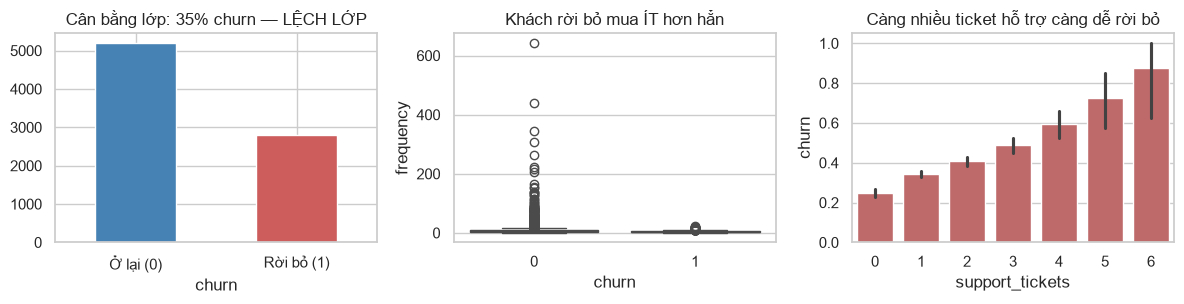

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
kh["churn"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "indianred"], rot=0)
axes[0].set_title(f"Cân bằng lớp: {kh['churn'].mean():.0%} churn — LỆCH LỚP")
axes[0].set_xticklabels(["Ở lại (0)", "Rời bỏ (1)"])
sns.boxplot(data=du_lieu, x="churn", y="frequency", ax=axes[1],
            hue="churn", legend=False, palette=["steelblue", "indianred"])
axes[1].set_title("Khách rời bỏ mua ÍT hơn hẳn")
sns.barplot(data=du_lieu, x="support_tickets", y="churn", ax=axes[2], color="indianred")
axes[2].set_title("Càng nhiều ticket hỗ trợ càng dễ rời bỏ")
plt.tight_layout(); plt.show()

## 12.2. Chia train/test TRƯỚC mọi xử lý

`stratify=y` giữ đúng tỷ lệ churn ở cả hai phần. Chia **trước** khi fit bất cứ thứ gì: nếu scaler học trên toàn bộ dữ liệu, thông tin của tập test đã **rò rỉ** vào mô hình — điểm số sẽ đẹp giả tạo.

In [4]:
X = du_lieu.drop(columns=["customer_id", "churn"])
y = du_lieu["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Train: {len(X_train):,} ({y_train.mean():.1%} churn) | "
      f"Test: {len(X_test):,} ({y_test.mean():.1%} churn)")

Train: 6,000 (35.1% churn) | Test: 2,000 (35.1% churn)


## 12.3. Pipeline #1 — Logistic Regression

`ColumnTransformer` phân luồng tiền xử lý theo loại cột, rồi nối với mô hình thành **một Pipeline**. Gọi `.fit(X_train)` một lần — scaler, encoder, mô hình đều chỉ học từ train; gọi `.predict(X_thô)` — pipeline tự biến đổi rồi dự đoán. **Không còn cảnh "quên scale tập test".**

In [5]:
cot_so = ["age", "tenure_months", "support_tickets", "recency", "frequency", "monetary"]
cot_phan_loai = ["gender", "city"]

tien_xu_ly = ColumnTransformer([
    ("so", StandardScaler(), cot_so),
    ("phan_loai", OneHotEncoder(handle_unknown="ignore"), cot_phan_loai),
])

pipe_logreg = Pipeline([
    ("tien_xu_ly", tien_xu_ly),
    ("mo_hinh", LogisticRegression(max_iter=1000, random_state=42)),
])
pipe_logreg.fit(X_train, y_train)
pipe_logreg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tien_xu_ly', ...), ('mo_hinh', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['age','gender','city',...,'recency','frequency','monetary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('so', ...), ('phan_loai', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remainin

## 12.4. Pipeline #2 — Decision Tree (chọn độ sâu bằng cross-validation)

Cây quyết định không cần scale nhưng vẫn đi qua cùng `ColumnTransformer` (để pipeline nhận đúng dữ liệu thô). Độ sâu là nút vặn overfitting: chọn bằng `GridSearchCV` 5-fold **chỉ trên train** — tập test tuyệt đối không tham gia chọn tham số.

In [6]:
pipe_tree = Pipeline([
    ("tien_xu_ly", tien_xu_ly),
    ("mo_hinh", DecisionTreeClassifier(random_state=42)),
])
tim_kiem = GridSearchCV(pipe_tree,
                        {"mo_hinh__max_depth": [3, 4, 5, 6, 8, 10, None]},
                        cv=5, scoring="roc_auc", n_jobs=-1)
tim_kiem.fit(X_train, y_train)
pipe_tree = tim_kiem.best_estimator_

bang_cv = pd.DataFrame(tim_kiem.cv_results_)[["param_mo_hinh__max_depth", "mean_test_score"]]
bang_cv.columns = ["max_depth", "ROC-AUC (CV 5-fold)"]
print(bang_cv.round(4).to_string(index=False))
print(f"\nChọn max_depth = {tim_kiem.best_params_['mo_hinh__max_depth']}"
      f" — cây quá sâu HỌC THUỘC train, AUC kiểm định tụt xuống.")

max_depth  ROC-AUC (CV 5-fold)
        3               0.7272
        4               0.7369
        5               0.7400
        6               0.7263
        8               0.6993
       10               0.6685
     None               0.5876

Chọn max_depth = 5 — cây quá sâu HỌC THUỘC train, AUC kiểm định tụt xuống.


## 12.5. Đánh giá: Confusion Matrix, Precision/Recall, ROC-AUC

Với 35% churn, mô hình "đoán bừa tất cả ở lại" đã đạt accuracy 65% — vì thế cần cả bộ thước đo:

| Thước đo | Câu hỏi kinh doanh |
|:---|:---|
| **Precision** (lớp churn) | gọi điện giữ chân 100 khách bị gắn cờ, bao nhiêu người thật sự định đi? |
| **Recall** (lớp churn) | trong số khách sắp đi, ta phát hiện được bao nhiêu %? |
| **ROC-AUC** | xếp hạng: xác suất mô hình chấm khách churn cao hơn khách ở lại |

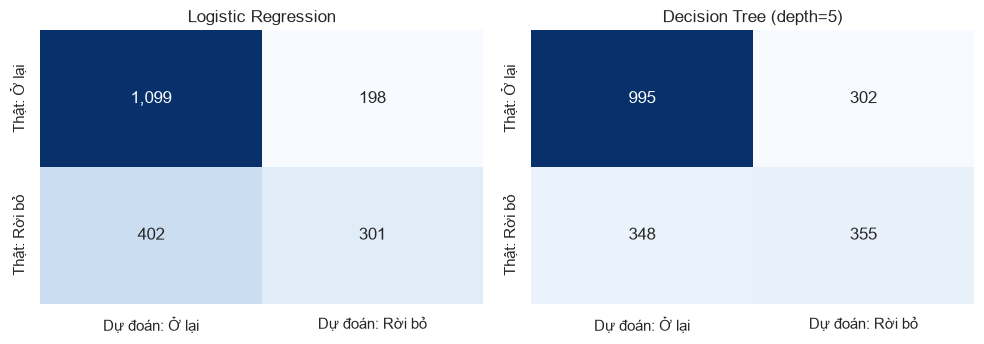

=== Logistic Regression ===
              precision    recall  f1-score   support

       Ở lại       0.73      0.85      0.79      1297
      Rời bỏ       0.60      0.43      0.50       703

    accuracy                           0.70      2000
   macro avg       0.67      0.64      0.64      2000
weighted avg       0.69      0.70      0.69      2000



In [7]:
du_doan_lr = pipe_logreg.predict(X_test)
du_doan_dt = pipe_tree.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, du_doan, ten in [(axes[0], du_doan_lr, "Logistic Regression"),
                         (axes[1], du_doan_dt, f"Decision Tree (depth={tim_kiem.best_params_['mo_hinh__max_depth']})")]:
    cm = confusion_matrix(y_test, du_doan)
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Dự đoán: Ở lại", "Dự đoán: Rời bỏ"],
                yticklabels=["Thật: Ở lại", "Thật: Rời bỏ"])
    ax.set_title(ten)
plt.tight_layout(); plt.show()

print("=== Logistic Regression ===")
print(classification_report(y_test, du_doan_lr, target_names=["Ở lại", "Rời bỏ"]))

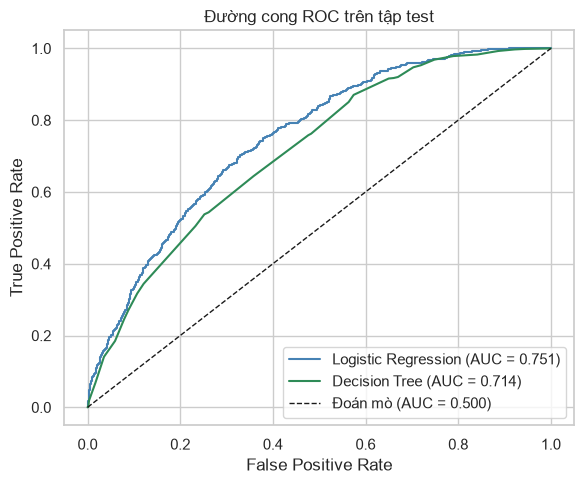

In [8]:
xac_suat_lr = pipe_logreg.predict_proba(X_test)[:, 1]
xac_suat_dt = pipe_tree.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
for xs, ten, mau in [(xac_suat_lr, "Logistic Regression", "steelblue"),
                     (xac_suat_dt, "Decision Tree", "seagreen")]:
    fpr, tpr, _ = roc_curve(y_test, xs)
    ax.plot(fpr, tpr, color=mau, label=f"{ten} (AUC = {roc_auc_score(y_test, xs):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Đoán mò (AUC = 0.500)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Đường cong ROC trên tập test")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Nút vặn ngưỡng (threshold):** mặc định gắn cờ churn khi xác suất > 0.5. Chiến dịch giữ chân thường muốn **vớt được nhiều khách sắp đi hơn** (tăng Recall) và chấp nhận gọi nhầm (giảm Precision) — chỉ cần hạ ngưỡng, **không cần huấn luyện lại**:

In [9]:
bang_nguong = []
for nguong in [0.5, 0.4, 0.3]:
    du_doan = (xac_suat_lr >= nguong).astype(int)
    bang_nguong.append([nguong,
                        f"{precision_score(y_test, du_doan):.1%}",
                        f"{recall_score(y_test, du_doan):.1%}",
                        f"{du_doan.sum():,} khách"])
print(pd.DataFrame(bang_nguong,
      columns=["Ngưỡng", "Precision (churn)", "Recall (churn)", "Phải chăm sóc"])
      .to_string(index=False))
print("\nChọn ngưỡng là quyết định KINH DOANH (chi phí gọi nhầm vs mất khách), không phải kỹ thuật.")

 Ngưỡng Precision (churn) Recall (churn) Phải chăm sóc
    0.5             60.3%          42.8%     499 khách
    0.4             55.3%          62.6%     795 khách
    0.3             48.8%          79.2%   1,142 khách

Chọn ngưỡng là quyết định KINH DOANH (chi phí gọi nhầm vs mất khách), không phải kỹ thuật.


## 12.6. Bảng đo metric, diễn giải mô hình và lưu deliverable

In [10]:
pipe_dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

bang_metric = []
for ten, pipe, xs in [("Baseline (đoán toàn bộ Ở lại)", pipe_dummy, None),
                      ("Logistic Regression", pipe_logreg, xac_suat_lr),
                      ("Decision Tree", pipe_tree, xac_suat_dt)]:
    du_doan = pipe.predict(X_test)
    bang_metric.append({
        "mo_hinh": ten,
        "accuracy": round(accuracy_score(y_test, du_doan), 3),
        "precision_churn": round(precision_score(y_test, du_doan, zero_division=0), 3),
        "recall_churn": round(recall_score(y_test, du_doan, zero_division=0), 3),
        "f1_churn": round(f1_score(y_test, du_doan, zero_division=0), 3),
        "roc_auc": round(roc_auc_score(y_test, xs), 3) if xs is not None else 0.5,
    })
bang_metric = pd.DataFrame(bang_metric)
print(bang_metric.to_string(index=False))
bang_metric.to_csv(PROCESSED / "lab12_metrics.csv", index=False)
print("\nBaseline accuracy cao mà recall = 0 — bằng chứng sống vì sao accuracy không đủ.")

                      mo_hinh  accuracy  precision_churn  recall_churn  f1_churn  roc_auc
Baseline (đoán toàn bộ Ở lại)     0.648            0.000         0.000     0.000    0.500
          Logistic Regression     0.700            0.603         0.428     0.501    0.751
                Decision Tree     0.675            0.540         0.505     0.522    0.714

Baseline accuracy cao mà recall = 0 — bằng chứng sống vì sao accuracy không đủ.


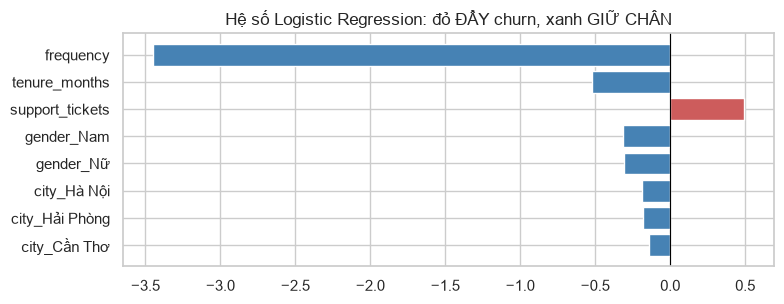

In [11]:
# Mô hình nói gì? — hệ số logistic (trên đặc trưng đã chuẩn hóa)
ten_dac_trung = (cot_so + list(pipe_logreg.named_steps["tien_xu_ly"]
                 .named_transformers_["phan_loai"].get_feature_names_out(cot_phan_loai)))
he_so = pd.Series(pipe_logreg.named_steps["mo_hinh"].coef_[0], index=ten_dac_trung)
he_so = he_so.reindex(he_so.abs().sort_values(ascending=False).index)[:8]

fig, ax = plt.subplots(figsize=(8, 3.2))
mau = ["indianred" if v > 0 else "steelblue" for v in he_so[::-1]]
ax.barh(he_so.index[::-1], he_so[::-1], color=mau)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Hệ số Logistic Regression: đỏ ĐẨY churn, xanh GIỮ CHÂN")
plt.tight_layout(); plt.show()

In [12]:
import joblib
joblib.dump(pipe_logreg, PROCESSED / "churn_model.joblib")
print("Đã lưu", PROCESSED / "churn_model.joblib")

# Chứng minh pipeline "đóng gói trọn": nạp lại và chấm 3 khách hàng THÔ
mo_hinh_moi = joblib.load(PROCESSED / "churn_model.joblib")
vi_du = X_test.iloc[:3]
print("\n3 khách hàng thô (chưa scale, chưa encode) -> xác suất churn:")
print(pd.DataFrame({"xac_suat_churn": mo_hinh_moi.predict_proba(vi_du)[:, 1].round(3)},
                   index=vi_du.index).join(vi_du[["support_tickets", "frequency", "tenure_months"]]))

Đã lưu ../data/processed/churn_model.joblib

3 khách hàng thô (chưa scale, chưa encode) -> xác suất churn:
      xac_suat_churn  support_tickets  frequency  tenure_months
1604           0.364                1        7.0              8
7252           0.621                2        4.0             15
7621           0.514                1        4.0             16


---
## TỔNG KẾT BUỔI 12

| Nguyên tắc | Bằng chứng trong bài |
|:---|:---|
| Chia train/test trước, stratify | 12.2 — tỷ lệ churn giữ nguyên ở cả hai phần |
| Tiền xử lý nằm trong Pipeline | 12.3/12.6 — nạp lại model là chấm được khách hàng THÔ |
| Chọn tham số bằng CV trên train | 12.4 — cây quá sâu tụt AUC kiểm định |
| Accuracy không đủ với lệch lớp | 12.6 — baseline accuracy cao nhưng recall = 0 |
| Ngưỡng là quyết định kinh doanh | 12.5 — hạ ngưỡng đổi Precision lấy Recall |

Chuỗi bài đã đi trọn 4 bậc: Descriptive (8) ➔ Diagnostic (9) ➔ Predictive (10, 12) — và mô hình churn này chính là đầu vào cho bậc **Prescriptive**: nên chi bao nhiêu, giữ chân ai trước.

---
# BÀI TẬP VỀ NHÀ

#### Bài tập 1: Thêm pipeline thứ ba dùng `RandomForestClassifier` (n_estimators=200), đưa vào bảng metric và đường ROC. Rừng có thắng cây đơn không? Vì sao?

In [13]:
# --- BÀI TẬP 1 ---


#### Bài tập 2: Dùng `GridSearchCV` tìm `C` tốt nhất cho Logistic Regression trong dải [0.01, 0.1, 1, 10, 100] (scoring="roc_auc"). C nhỏ nghĩa là gì và ảnh hưởng thế nào tới hệ số?

In [14]:
# --- BÀI TẬP 2 ---


#### Bài tập 3 (Bài toán chi phí): Giả sử gọi giữ chân một khách tốn 50 nghìn đ, mất một khách churn tốn 400 nghìn đ. Với `xac_suat_lr`, tính tổng chi phí ở các ngưỡng 0.1 ➔ 0.9 (bước 0.1) và tìm ngưỡng tối ưu. Ngưỡng đó có phải 0.5 không?

In [15]:
# --- BÀI TẬP 3 ---
